Домашнее задание. Логистическая регрессия и разные виды линейной регрессии (с регуляризацией)

### Задача 1: Первичный анализ данных House Prices(1 балл)

Датасет: [House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/overview)

Требуется:

- Загрузите данные и выполните первичный анализ

- Проведите анализ распределения целевой переменной SalePrice

- Выявите и обработайте пропущенные значения в данных

In [2]:
! gdown 1SKx5Shx5J1O45mKBmjCtQmUF7LXRUou-

Downloading...
From: https://drive.google.com/uc?id=1SKx5Shx5J1O45mKBmjCtQmUF7LXRUou-
To: /content/train.csv
100% 461k/461k [00:00<00:00, 14.6MB/s]


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [74]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


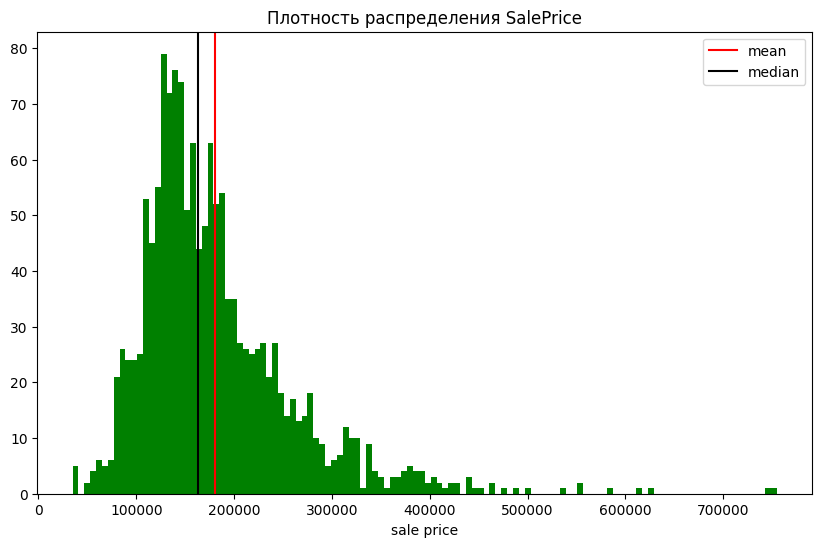

In [75]:
plt.figure(figsize=(10, 6))
plt.hist(df['SalePrice'], bins=120, color='g')
plt.title('Плотность распределения SalePrice')
plt.axvline(df['SalePrice'].mean(), label='mean', color='r')
plt.axvline(df['SalePrice'].median(), label='median', color='black')
plt.xlabel('sale price')
plt.legend()
plt.show()

In [76]:
print(df['SalePrice'].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [77]:
null_d = []
for column in df:
    if df[column].isnull().any():
        null_count = df[column].isnull().sum()
        null_percent = (null_count / len(df)) * 100
        null_d.append((column, null_percent))

print("Колонки с пропущенными значениями:")
for col_info in null_d:
    print(f"{col_info[0]}: пропусков ({col_info[1]:.2f}%)")

Колонки с пропущенными значениями:
LotFrontage: пропусков (17.74%)
Alley: пропусков (93.77%)
MasVnrType: пропусков (59.73%)
MasVnrArea: пропусков (0.55%)
BsmtQual: пропусков (2.53%)
BsmtCond: пропусков (2.53%)
BsmtExposure: пропусков (2.60%)
BsmtFinType1: пропусков (2.53%)
BsmtFinType2: пропусков (2.60%)
Electrical: пропусков (0.07%)
FireplaceQu: пропусков (47.26%)
GarageType: пропусков (5.55%)
GarageYrBlt: пропусков (5.55%)
GarageFinish: пропусков (5.55%)
GarageQual: пропусков (5.55%)
GarageCond: пропусков (5.55%)
PoolQC: пропусков (99.52%)
Fence: пропусков (80.75%)
MiscFeature: пропусков (96.30%)


Удалим все ячейки, где больше 80% пропусков

In [78]:
df = df.drop(['MiscFeature', 'Fence', 'PoolQC', 'Alley'], axis=1)

MasVnr - облицовка, если в датасете ничего нет, вероятно, облицовки просто нет (None), а её площадь равна 0. Аналогичная история с камином (и его отсутствием)

In [ ]:
df['MasVnrType'].fillna('None', inplace=True)
df['MasVnrArea'].fillna(0, inplace=True)

df['FireplaceQu'].fillna('No Fireplace', inplace=True)

Аналогично пределываем заполнение пустых значения во всех признаках, которые как-то связаны с гаражом. Если гаража нет, то нет и других параметров.

In [107]:
for col in null_d:
  column = col[0]
  if column.startswith('Garage') and column != 'GarageYrBlt':
      df[column].fillna('None', inplace=True)
  if column == 'GarageYrBlt':
    df[column].fillna(0, inplace=True)

Аналогичным образом поступим с данными о подвале.

In [ ]:
for col in null_d:
    column = col[0]
    if column.startswith('Bsmt'):
        df[column].fillna('None', inplace=True)

Расстояние перед домом будем заполнять просто средним значением.

In [ ]:
df['LotFrontage'].fillna(df['LotFrontage'].mean(), inplace=True)

Электрическая система отсутствует в очень маленьком проценте данных, поэтому заполним модой.

In [ ]:
df['Electrical'].fillna(df['Electrical'].mode()[0], inplace=True)

In [112]:
flag = False
for column in df:
    if df[column].isnull().any():
        flag = True
if not flag:
  print("Пропущенных значений не осталось")

Пропущенных значений не осталось


### Задача 2: Построение базовой модели (1 балл)

Требуется:

- Разделите данные на обучающую и тестовую выборки в соотношении 80/20

- Обучите модель LinearRegression на обучающей выборке, используя только числовые признаки

- Выберите метрику для сравнения моделей и обоснуйте свой выбор
- Рассчитайте свою метрику на тестовой выборке

In [164]:
import sklearn
df.drop('Id', axis=1, inplace=True)
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=36)

In [165]:
numeric = X_train.select_dtypes(include=[np.number]).columns
X_train_numeric = X_train[numeric]
X_test_numeric = X_test[numeric]

In [166]:
model = sklearn.linear_model.LinearRegression()
model.fit(X_train_numeric, y_train)
y_pred = model.predict(X_test_numeric)

In [167]:
mae = sklearn.metrics.mean_absolute_error(y_test, y_pred)

print(f"Результаты модели \nMAE: {mae:,.2f}")

Результаты модели 
MAE: 23,075.93


**Обоснование выбора метрики:**

В первом задании нужно было рассмотреть, как распределена SalePrice. И по графику видно, что у данных много выбросов, а засчёт того, что каждое слагаемое суммы не возводится в квадрат (как в RMSE или MSE), а берётся по модулю, эта метрика меньше подвержена воздействию упомянутых выше выбросов. Также, так как MAE представляет среднюю величину ошибок в оригинальных единицах целевой переменной, то в нашем случае мы получили среднюю ошибку в валюте измерения, что удобно для анализа и понимания качества.

### Задача 3: Предобработка данных и интерпретация модели (2 балл)

Требуется:

- Закодируйте категориальные переменные методами One-Hot Encoding или Label Encoding

- Масштабируйте числовые признаки с помощью StandardScaler

- Обучите LinearRegression на обучающих данных и оцените качество на тестовых данных по выбранной метрике

- Выведите 5 самых важных признаков по абсолютному значению коэффициентов

- Проанализируйте, какие факторы больше всего влияют на модель

Подсказка:
Зачем вообще нужен StandardScaler и One-Hot Encoding или Label Encoding ?

1) StandardScaler - для чего нужен:
- Нормализует масштаб числовых признаков (приводит к среднему=0, std=1)
- Зачем: Многие алгоритмы ML чувствительны к масштабу данных.
Пример проблемы: Признак "Площадь дома" (100-300 м²) и "Количество комнат" (1-5)без масштабирования алгоритм придаст больше веса площади, но после масштабирования - оба признака будут в одинаковом масштабе.

2) One-Hot Encoding/Label Encoding - для чего нужны:

- Label Encoding : Преобразует категории в числа. Сохраняет размерность данных, но может создать ложную порядковость (0 < 1 < 2)!

- One-Hot Encoding: Создает бинарные столбцы для каждой категории.Убирает ложную порядковость, но увеличивает размерность данных (проклятие размерности)

Сначала разделим колонки на два типа: числовые и категориальные. Затем с помощью встроенной функции применим one-hot encoding для категориальных признаков (они будут именоваться "category_{название категории}"), а затем уже для числовых признаком применим нормализацию после деления на обучающую и тестовую часть

In [168]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

numeric = df.select_dtypes(include=[np.number]).columns.drop('SalePrice')
category = df.drop(numeric, axis=1).drop('SalePrice', axis=1).columns

df_onehot = pd.get_dummies(df, columns=category, prefix=category, drop_first=True)
df_onehot.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


In [169]:
scaler = StandardScaler()
X = df_onehot.drop(['SalePrice'], axis=1)
y = df_onehot['SalePrice']

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=36)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric] = scaler.fit_transform(X_train[numeric])
X_test_scaled[numeric] = scaler.transform(X_test[numeric])

In [170]:
model = sklearn.linear_model.LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
mae = sklearn.metrics.mean_absolute_error(y_test, y_pred)
print(f"Результаты модели с предобработкой \nMAE: {mae:.2f}")

Результаты модели с предобработкой 
MAE: 20788.49


In [175]:
feature = pd.DataFrame({'feature': X_train.columns, 'abs_coef': np.abs(model.coef_)})
top_5 = feature.sort_values('abs_coef', ascending=False).head(5)
print(top_5)

              feature       abs_coef
115  RoofMatl_WdShngl  749966.701726
111    RoofMatl_Metal  744544.405436
113  RoofMatl_Tar&Grv  705718.857866
109  RoofMatl_CompShg  696362.565398
112     RoofMatl_Roll  679879.511128


Выводы:
Модель с предобработанными данными в среднем ошибается на 3000 денежных единиц меньше, чем модель без предобработки, и показывает хороший результат (MAE всего 20788). Но если мы посмотрим на признаки с наибольшим весом, мы увидим там всё, что связано с крышей, что из логических соображений может быть неверным. Это наталкивает на мысль, что предобработка была неидеальной. Скорее всего эти признаки были достаточно редки, и у них высокая корреляция с признаками, которые на самом деле в большей степени определеяют стоимость жилья, поэтому модель ошибочко считает их "важными". Возможно, в следующий раз стоит проверять признаки на корреляцию и зависимость друг от друга или научиться и пользоваться другими техниками предобработки.

### Задача 4: Регуляризация и подбор гиперпараметров (1 балл)

Требуется:

- Создайте Pipeline с MinMaxScaler и ElasticNet, подберите оптимальные параметры (alpha, l1_ratio) с помощью GridSearchCV

- Создайте Pipeline с StandardScaler и ElasticNet, подберите оптимальные параметры (alpha, l1_ratio) с помощью GridSearchCV

- Для оценки качества используйте выбранную ранее метрику

In [185]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import ElasticNet

pipe_1 = Pipeline([
    ('step1', MinMaxScaler()),
    ('step2', ElasticNet(max_iter=10000, tol=0.01))
])

pipe_2 = Pipeline([
    ('step1', StandardScaler()),
    ('step2', ElasticNet(max_iter=10000, tol=0.01))
])

Для параметра alpha (сила регуляризации) будем использовать логарифмическую шкалу, а для определения баланса между l1 и l2 будет использовать привычную линейную шкалу.

In [188]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'step2__alpha': list(np.logspace(-2, 1, 2)),
    'step2__l1_ratio': list(np.arange(0.1, 1.1, 0.1))
}

In [191]:
import warnings
warnings.filterwarnings('ignore')

grid_minmax = GridSearchCV(pipe_1, param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_minmax.fit(X_train, y_train)
print("Лучшие параметры minmax:", grid_minmax.best_params_)
print("Лучший MAE minmax:", -grid_minmax.best_score_)
grid_standard = GridSearchCV(pipe_2, param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_standard.fit(X_train, y_train)
print("Лучшие параметры standart:", grid_standard.best_params_)
print("Лучший MAE standart:", -grid_standard.best_score_)

Лучшие параметры minmax: {'step2__alpha': np.float64(0.01), 'step2__l1_ratio': np.float64(0.30000000000000004)}
Лучший MAE minmax: 18186.924678366217
Лучшие параметры standart: {'step2__alpha': np.float64(10.0), 'step2__l1_ratio': np.float64(0.9)}
Лучший MAE standart: 18652.014166557357


In [218]:
m = grid_minmax.best_estimator_.named_steps['step2']
feature = pd.DataFrame({'feature': X_train.columns,'abs_coef': np.abs(m.coef_[0])})
top_5 = feature.sort_values('abs_coef', ascending=False).head(5)
print("minmax: \n", top_5)

m = grid_standard.best_estimator_.named_steps['step2']
feature = pd.DataFrame({'feature': X_train.columns,'abs_coef': np.abs(m.coef_[0])})
top_5 = feature.sort_values('abs_coef', ascending=False).head(5)
print("\nstandard: \n", top_5)

minmax: 
        feature      abs_coef
0   MSSubClass  17640.024425
1  LotFrontage  17640.024425
2      LotArea  17640.024425
3  OverallQual  17640.024425
4  OverallCond  17640.024425

standard: 
        feature    abs_coef
0   MSSubClass  1870.25076
1  LotFrontage  1870.25076
2      LotArea  1870.25076
3  OverallQual  1870.25076
4  OverallCond  1870.25076


In [195]:
print("MinMax зануленные:", list(X_train.columns[grid_minmax.best_estimator_.named_steps['step2'].coef_ == 0]))
print("Standard зануленные:", list(X_train.columns[grid_standard.best_estimator_.named_steps['step2'].coef_ == 0]))

MinMax зануленные: ['Condition2_PosA', 'RoofMatl_Membran', 'Exterior1st_BrkComm', 'Exterior2nd_Other']
Standard зануленные: ['BsmtHalfBath', 'Condition2_PosA', 'RoofMatl_Membran', 'Exterior1st_BrkComm', 'Exterior2nd_Other']


### Вопросы для анализа:(1 балл)

1. Сравните оптимальные параметры в двух экспериментах

2. Сравните качество модели на тестовой выборке в обоих случаях

3. Проанализируйте, какие признаки были занулены в каждом эксперименте и объясните возможные причины

4. Сделайте вывод о влиянии типа масштабирования на качество линейной регрессии

Ответ на вопрос:
1. MinMaxScaler требует слабой регуляризации (alpha=0.01) и l1_ratio=0.3;
StandardScaler нуждается в сильной регуляризации (alpha=10.0) с преобладанием L1 (так как l1_ratio=0.9). В двух пунктах я получила абсолютно разные значения параметров. Отсюда нужно сделать логичный вывод: для каждой модели параметры подбираются индивидуально. А конкретно в нашем случае тип регуляризации сильно зависит от типа модели. Более того, такой подбор параметров позволяет значительно улучшить результат (на 5000 денежных единиц, что в нашем случае составляет 20% от изначального MAE).
2. Во втором случае мы получили MAE на 500 денежных единиц больше. Это примерно 2.5%. Можем сказать, что для нашего датасета тип MinMaxScaler лучше.
3. Обе модели занулили 4 одинаковых признака, но standart занулила ещё и BSmtHalfBath. То, что признаки совпали, может говорит о корректности моделей и о том, что они действительно правильно выбирают веса для признаков, по крайней мере для маловажных, и зануляют их.
'RoofMatl_Membran' - скорее всего редкий тип покрытия, из-за чего его отсутствие / наличие никак не сказывается на цене в общем случае. Аналогичное предположение можно сделать для 'Exterior1st_BrkComm' (если я не ошибаюсь, это тип кирпича, который тоже можно встретить нечасто). 'Condition2_PosA' - это что-то, связанное с локацией и расположением. В датасете много признаков, которые учитывают расположение относительно ключевых точек города, дорог и прочих признаков, поэтому, возможно, у этого признака просто большая корреляция с уже учтёнными и ненулевыми факторами расположения. 'Exterior2nd_Other' - это "остаточный" признак отделки, куда могут входить как дорогие, так и недорогие материалы, из-за чего признак становится неинформативным и зануляется.
4. В нашем случае minmax проявил себя лучше. Несмотря на то, что он менее устойчив к выбросам, он позволяет сохранять некоторые "естественные" параметры и ограничивать их. Например, количество комнат и цена ограничены снизу 0. В интернете я также наткнулась на обсуждение того, что minmax наиболее благоприятен для линейной модели, так как после обработки данные остаются сравнимыми между собой, что для линейной модели является более интерпретируемым. Об этом говорит и то, что потребовалась слабая регуляризация. Поэтому minmax показал лучшие результаты для нашей линейной модели.

### Задача 5: Бинарная классификация с помощью логистической регрессии (2 балла)

Требуется:

- Создайте бинарную целевую переменную expensive (1 - если цена выше медианы, 0 - в противном случае)

- Обучите модель LogisticRegression с L2-регуляризацией

- Выполните подбор гиперпараметров с помощью GridSearchCV

- Оцените качество модели с помощью метрики F1-score

- Для лучшей модели выведите Топ-5 самых важных признаков

Примечание: Не забудьте разделить данные на обучающую и тестовую выборки перед обучением модели с тем же random_state.

In [198]:
df['expensive'] = (df['SalePrice'] > df['SalePrice'].median()).astype(int)
X = df.drop(['SalePrice', 'expensive'], axis=1)
y = df['expensive']

In [206]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=36)

pipe = Pipeline([
    ('step1', StandardScaler()),
    ('step2', LogisticRegression(penalty='l2', max_iter=1000, random_state=36))
])

param_grid = {
    'step2__C': np.logspace(-3, 3, 5)
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
f1 = sklearn.metrics.f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"F1-score на X_test: {f1:.4f}")

Лучшие параметры: {'step2__C': np.float64(0.03162277660168379)}
F1-score на X_test: 0.9393


In [210]:
m = best_model.named_steps['step2']
feature = pd.DataFrame({'feature': X_encoded.columns,'abs_coef': np.abs(m.coef_[0])})
top_5 = feature.sort_values('abs_coef', ascending=False).head(5)
print(top_5)

        feature  abs_coef
18     FullBath  0.390845
15    GrLivArea  0.373233
25   GarageCars  0.309977
3   OverallQual  0.306636
12     1stFlrSF  0.300538


### Проанализируй все модели и ответе на вопросы :(2 балла)

1) Какая модель показала наилучшие результаты для регрессии и почему?

2) Как регуляризация повлияла на веса признаков?

3) Какие признаки оказались наиболее важными для предсказания цены дома?

4) Насколько хорошо логистическая регрессия справилась с бинарной классификацией?

5) Какие проблемы в данных могли повлиять на качество моделей?

Ответ на вопросы:
1. Лучшей оказалась ElasticNet с MinMaxScaler. Во-первых, там встречается наиболее подходящая для линейной регрессии обработка данных (а именно minmax), о чём я уже писала ранее в 4 задании. Minmax сохраняет отношения между значениями, а также логические границы. ElasticNet содержит в себе 2 регуляризации, которые при правильном подбора параметров защитили модель от переобучения и позволили получить наилучшее значение MAE.
2. Регуляризация занулила несколько признаков, в случае с minmax - плавно уменьшал веса (так как alpha маленькая), в случае с standad - произошла наоборот сильная l1 регуляризация, что уменьшило влияние признаков (и даже занулило на 1 признак больше), а коэффициенты стали значительно меньше коэффициентов на minmax.
3. На этот вопрос однозначно ответить нельзя, так как я не согласна с тем, что у меня получился достаточно хороший результат в задании 2 (так как top-5 признаков были из одной категории и немного противоречили здравому смыслу), и я предполагаю, что это произошло из-за не совсем подходящей предобработки и переобучения модели из-за отсутствия регуляризации. Но на остальных моделях (в том числе на последней) список содержит одну и ту же: 'OverallQual'.
4. F-1 score показал очень высокий результат - 0.9393, что говорит о том, что модель справилась хорошо.
5.
- Пропуски в значениях -> решение: заполнить пропуски наиболее подходящим способом (средним, модой, специальным значением и др.)
- Большой разброс данных, выбросы -> решение: сделать нормализацию данных (например, minmax для линейной регрессии)
- Корреляция признаков -> решение: удалить один из признаков или преобразовать его, используя свои знания о датасете (например, периметр прямоугольника сильно коррелирует с его шириной, и периметр можно было бы заменить на длину, посчитав её из известных данных)
- редкие категории, что ведёт в переобучению -> решение: удалить/ объединить в одну